GPU wird benutzt.
Device: mps
Accuracy vom geladenen Modell: 0.9724770642201835

Epoch 1/2
Trainingsloss: 0.05443091983241694
Trainingsaccuracy: 0.9862385321100917


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.3785625].


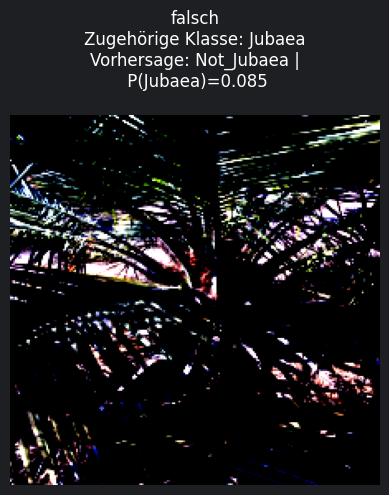

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.64].


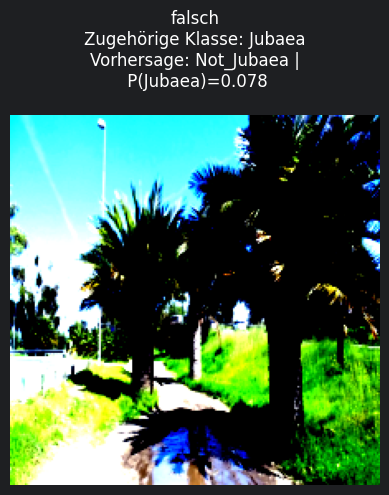

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781512..2.64].


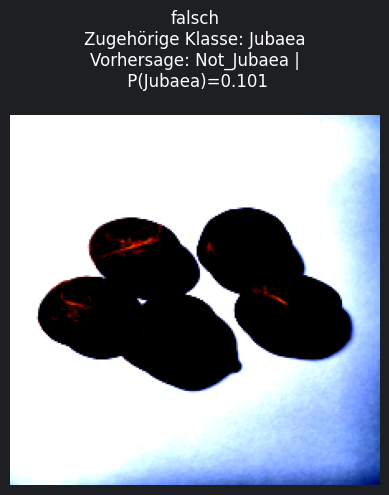

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.535425].


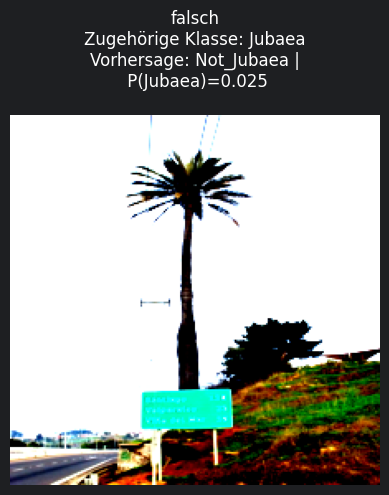

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..1.5296686].


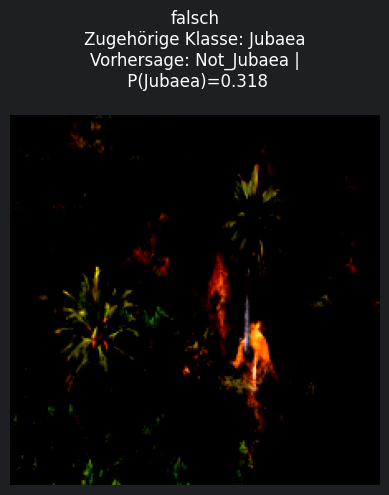

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..1.5810429].


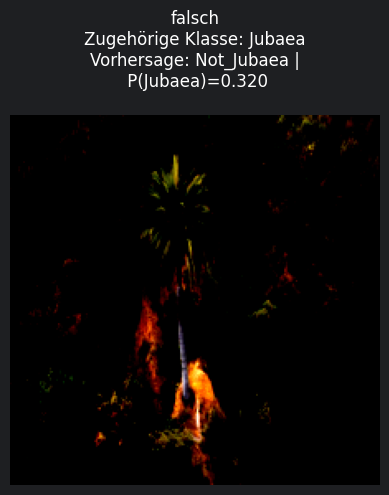

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7754089..2.4308496].


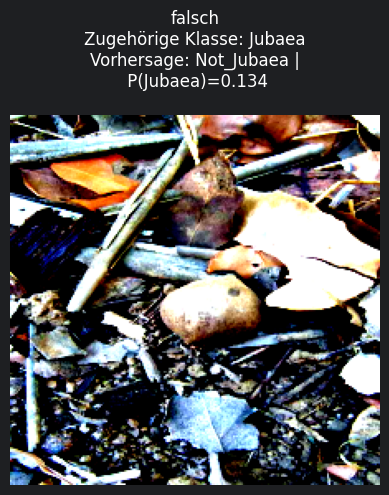

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.3611329].


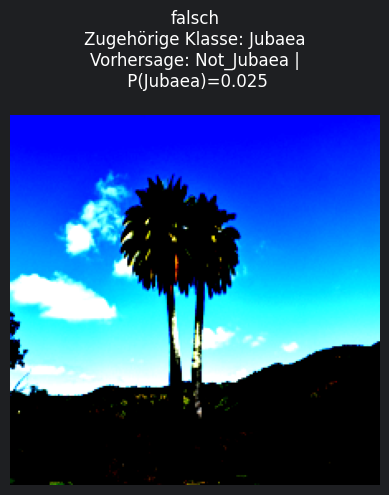

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].


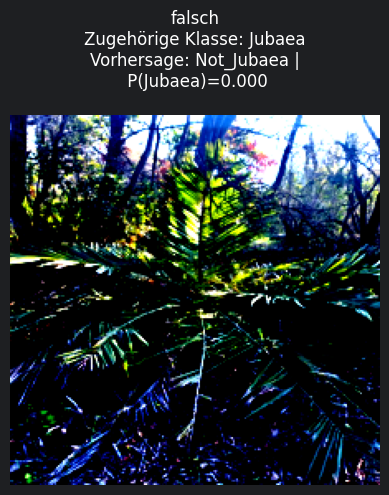

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].


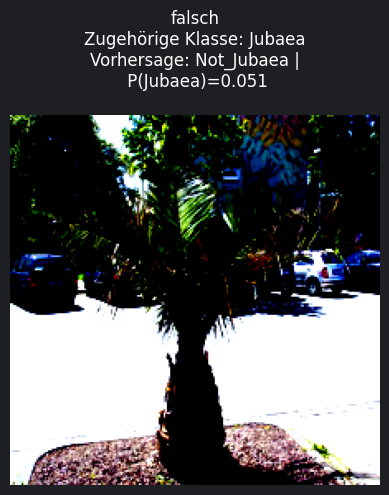

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.64].


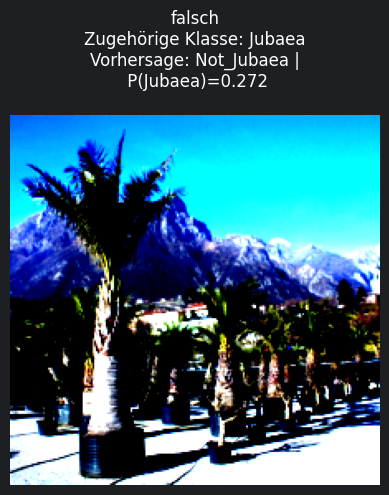

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8256302..2.64].


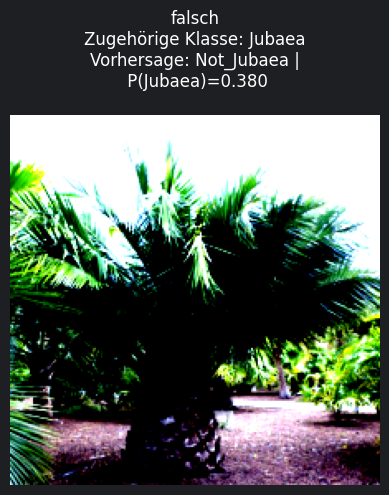

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.6051416].


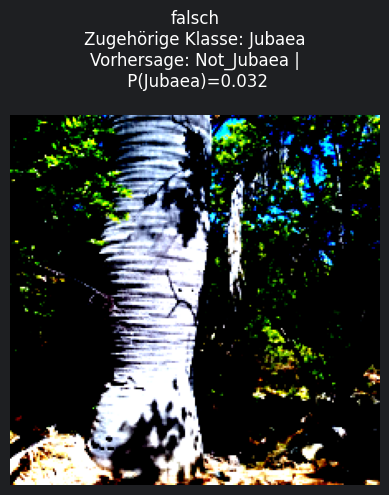

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].


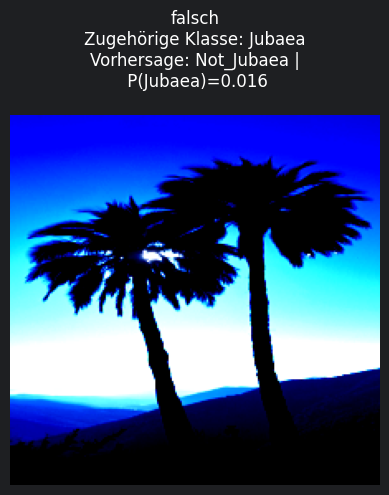

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.622571].


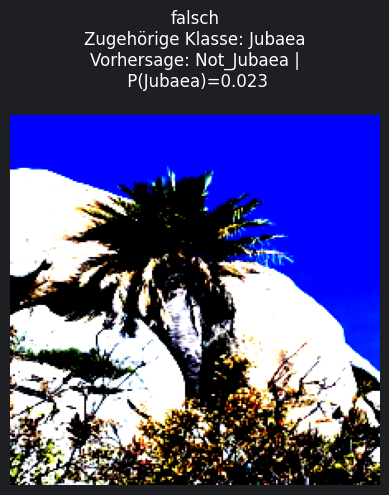

Testaccuracy: 0.8623853211009175
Beste Accuracy bisher: 0.9724770642201835

Epoch 2/2
Trainingsloss: 0.017517832373934134
Trainingsaccuracy: 0.9931192660550459


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.4482791].


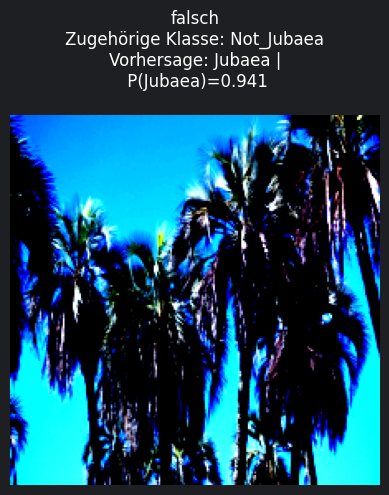

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.3785625].


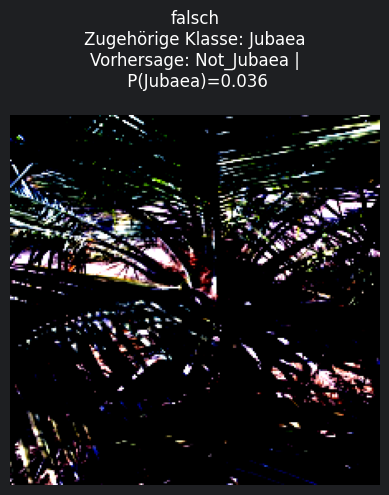

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].


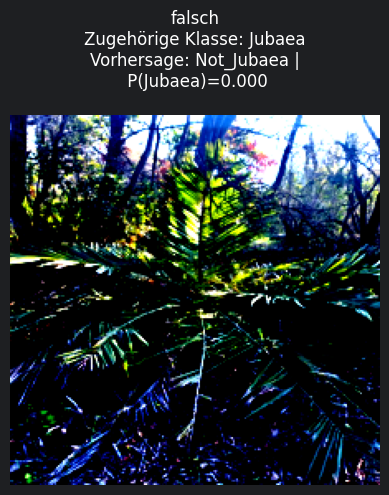

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].


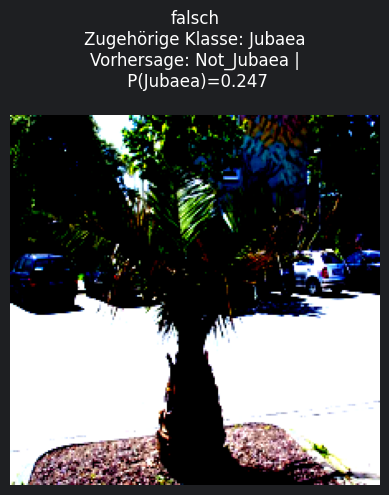

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


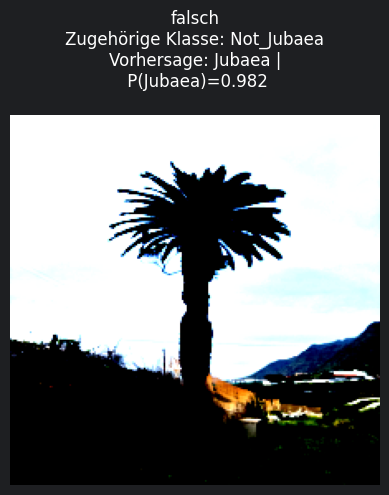

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.2535014].


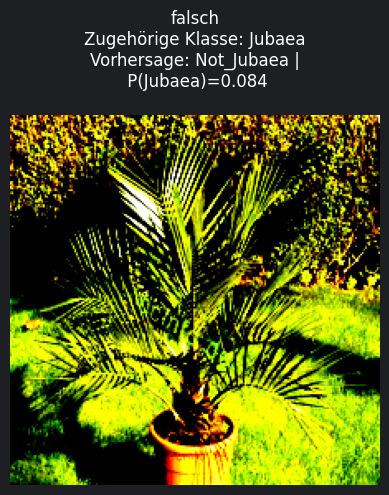

Testaccuracy: 0.944954128440367
Beste Accuracy bisher: 0.9724770642201835


In [3]:
import torch
import os

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision import models
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt



# GPU oder CPU auswählen

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("GPU wird benutzt.")
else:
    device = torch.device("cpu")
    print("CPU wird benutzt.")

print("Device:", device)


#  Daten importieren

def create_sample():
    sample = []

    jubaea_directory = "Data/Jubaea"

    for image in os.listdir(jubaea_directory):
        if image.lower().endswith((".jpg", ".jpeg", ".png")):
            sample.append(
                (os.path.join(jubaea_directory, image), 1)
            )

    not_jubaea_directory = "Data/Not_Jubaea"

    for subfolder in os.listdir(not_jubaea_directory):

        subfolder_path = os.path.join(
            not_jubaea_directory,
            subfolder
        )

        if not os.path.isdir(subfolder_path):
            continue

        for image in os.listdir(subfolder_path):

            if image.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):
                sample.append(
                    (
                        os.path.join(
                            not_jubaea_directory,
                            subfolder,
                            image
                        ),
                        0
                    )
                )

    return sample


sample = create_sample()

pictures = [x[0] for x in sample]
labels = [x[1] for x in sample]


X_train, X_test, Y_train, Y_test = train_test_split(
    pictures,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)



# Transformationen


# Werte, die beim ursprünglichen Training
# von ResNet18 auf ImageNet benutzt wurden
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]


# Resize + Data Augmentation + Normalisierung
train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomRotation(15),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])


# Test

test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])



# Dataset


class JubaeaDataset(Dataset):

    def __init__(
        self,
        paths,
        labels,
        transform=None
    ):

        self.paths = paths
        self.labels = labels
        self.transform = transform


    def __len__(self):
        return len(self.paths)


    def __getitem__(self, index):

        path = self.paths[index]

        label = self.labels[index]

        image = Image.open(path).convert("RGB")

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = JubaeaDataset(
    X_train,
    Y_train,
    transform=train_transform
)

test_dataset = JubaeaDataset(
    X_test,
    Y_test,
    transform=test_transform
)


train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


# ResNet18 laden


net = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)


# Bereits trainiertes Jubaea-Modell laden
net.load_state_dict(
    torch.load(
        "Jubaea_resnet.pth",
        map_location=device
    )
)


# GPU benutzen
net = net.to(device)



# 6. Aktuelles gespeichertes Modell testen

net.eval()

pre_correct = 0
pre_total = 0


with torch.no_grad():

    for images, labels in test_loader:

        # Daten auf GPU verschieben
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        pre_correct += (
            preds == labels
        ).sum().item()

        pre_total += labels.size(0)


model_acc = pre_correct / pre_total

print(
    "Accuracy vom geladenen Modell:",
    model_acc
)



# Lossfunktion

loss_fn = nn.CrossEntropyLoss()



# Optimizer

optimizer = torch.optim.Adam(
    net.parameters(),
    lr=0.0001,
    weight_decay=5e-4
)


# Training

epochs = 2

best_acc = model_acc

classes = [
    "Not_Jubaea",
    "Jubaea"
]

for epoch in range(epochs):

    net.train()

    loss_calc = 0.0

    correct_train = 0
    total_train = 0


    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)


        optimizer.zero_grad()       # Alte Gradienten löschen
        outputs = net(images)

        loss = loss_fn(             # Loss berechnen
            outputs,
            labels
        )


        loss.backward()             #Backpropagation

        # Gewichte verändern
        optimizer.step()

        loss_calc += loss.item()


        # Trainingsaccuracy berechnen

        preds = torch.argmax(
            outputs,
            dim=1
        )

        correct_train += (
            preds == labels
        ).sum().item()

        total_train += labels.size(0)


    epoch_loss = (
        loss_calc /
        len(train_loader)
    )

    train_acc = (
        correct_train /
        total_train
    )


    print()
    print(
        f"Epoch {epoch + 1}/{epochs}"
    )

    print(
        "Trainingsloss:",
        epoch_loss
    )

    print(
        "Trainingsaccuracy:",
        train_acc
    )


    # Test

    net.eval()

    correct_test = 0
    total_test = 0


    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)      #Testdaten auf GPU
            labels = labels.to(device)

            outputs = net(images)

            probs = torch.softmax(
                outputs,
                dim=1
            )

            preds = torch.argmax(
                outputs,
                dim=1
            )

            correct_test += (
                preds == labels
            ).sum().item()

            total_test += labels.size(0)



  # Zeigen von Fehlklassifikationen, bei mehreren Epochen ausschalten

            for i in range(len(images)):
                if preds[i] != labels[i]:
                    plt.imshow(images[i].detach().cpu().permute(1, 2, 0))
                    plt.title(
                        f"Falsch\n"
                        f"Zugehörige Klasse: {classes[labels[i].item()]}\n"
                        f"Vorhersage: {classes[preds[i].item()]} |\n "
                        f"P(Jubaea)={probs[i][1].item():.3f}\n"
                    )
                    plt.axis('off')
                    plt.show()



    test_acc = (
        correct_test /
        total_test
    )


    # Bestes Modell speichern

    if test_acc > best_acc:

        best_acc = test_acc

        torch.save(
            net.state_dict(),
            "Jubaea_resnet.pth"
        )

        print(
            "Neues bestes Modell gespeichert."
        )


    print(
        "Testaccuracy:",
        test_acc
    )

    print(
        "Beste Accuracy bisher:",
        best_acc
    )